In [1]:
import os
import sys
import warnings
import getpass
import json
import re

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL
from sqlalchemy import inspect

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
PROJECT_PATH = r"C:\Users\asus\Documents\ECOMMERCE-AI-PLATFORM"

DATA_PROCESSED_PATH = os.path.join(
    PROJECT_PATH,
    "data",
    "processed"
)

OUTPUT_PATH = os.path.join(
    DATA_PROCESSED_PATH,
    "customer_segmentation"
)

os.makedirs(OUTPUT_PATH, exist_ok=True)

print("Project path:")
print(PROJECT_PATH)

print("\nOutput path:")
print(OUTPUT_PATH)

print("\nProject path exists:", os.path.exists(PROJECT_PATH))
print("Processed data path exists:", os.path.exists(DATA_PROCESSED_PATH))
print("Customer segmentation output path exists:", os.path.exists(OUTPUT_PATH))

Project path:
C:\Users\asus\Documents\ECOMMERCE-AI-PLATFORM

Output path:
C:\Users\asus\Documents\ECOMMERCE-AI-PLATFORM\data\processed\customer_segmentation

Project path exists: True
Processed data path exists: True
Customer segmentation output path exists: True


In [3]:
PROJECT_PATH = r"C:\Users\asus\Documents\ECOMMERCE-AI-PLATFORM"

DATA_PROCESSED_PATH = os.path.join(
    PROJECT_PATH,
    "data",
    "processed"
)

OUTPUT_PATH = os.path.join(
    DATA_PROCESSED_PATH,
    "customer_segmentation"
)

os.makedirs(OUTPUT_PATH, exist_ok=True)

print("Project path:")
print(PROJECT_PATH)

print("\nOutput path:")
print(OUTPUT_PATH)

print("\nProject path exists:", os.path.exists(PROJECT_PATH))
print("Processed data path exists:", os.path.exists(DATA_PROCESSED_PATH))
print("Customer segmentation output path exists:", os.path.exists(OUTPUT_PATH))

Project path:
C:\Users\asus\Documents\ECOMMERCE-AI-PLATFORM

Output path:
C:\Users\asus\Documents\ECOMMERCE-AI-PLATFORM\data\processed\customer_segmentation

Project path exists: True
Processed data path exists: True
Customer segmentation output path exists: True


In [4]:
DB_HOST = "localhost"
DB_PORT = 5432
DB_NAME = "ecommerce_ai_db"

DB_USER = input("Enter your PostgreSQL username: ")
DB_PASSWORD = getpass.getpass("Enter your PostgreSQL password: ")

print("Database connection details collected securely.")
print("Password was not printed or stored in the notebook output.")

Enter your PostgreSQL username:  postgres
Enter your PostgreSQL password:  ········


Database connection details collected securely.
Password was not printed or stored in the notebook output.


In [5]:
DATABASE_URL = URL.create(
    drivername="postgresql+psycopg2",
    username=DB_USER,
    password=DB_PASSWORD,
    host=DB_HOST,
    port=DB_PORT,
    database=DB_NAME
)

engine = create_engine(
    DATABASE_URL,
    pool_pre_ping=True,
    future=True
)

try:
    with engine.connect() as connection:
        connection.execute(text("SELECT 1"))
    
    print("PostgreSQL connection successful!")
    print(f"Database: {DB_NAME}")
    print(f"Host: {DB_HOST}")
    print(f"Port: {DB_PORT}")

except Exception as error:
    print("PostgreSQL connection failed.")
    print("Error type:", type(error).__name__)
    print("Error message:", str(error))
    raise

PostgreSQL connection successful!
Database: ecommerce_ai_db
Host: localhost
Port: 5432


In [6]:
FEATURE_SCHEMA = "feature_engineered"
ANALYTICS_SCHEMA = "analytics"

print("Feature-engineered schema:", FEATURE_SCHEMA)
print("Analytics output schema:", ANALYTICS_SCHEMA)

Feature-engineered schema: feature_engineered
Analytics output schema: analytics


In [7]:
with engine.begin() as connection:
    connection.execute(
        text(
            f'CREATE SCHEMA IF NOT EXISTS "{ANALYTICS_SCHEMA}"'
        )
    )

print(f'Schema "{ANALYTICS_SCHEMA}" is available.')

Schema "analytics" is available.


In [8]:
schema_query = text("""
SELECT
    schema_name
FROM information_schema.schemata
WHERE schema_name NOT IN (
    'pg_catalog',
    'information_schema'
)
ORDER BY schema_name
""")

schemas_df = pd.read_sql(schema_query, engine)

print("Available PostgreSQL schemas:")
display(schemas_df)

Available PostgreSQL schemas:


,schema_name
0,analytics
1,feature_engineered
2,pg_toast
3,public
4,sales_analytics


In [9]:
tables_query = text("""
SELECT
    table_schema,
    table_name,
    table_type
FROM information_schema.tables
WHERE table_schema = :schema_name
ORDER BY table_name
""")

feature_tables_df = pd.read_sql(
    tables_query,
    engine,
    params={"schema_name": FEATURE_SCHEMA}
)

if feature_tables_df.empty:
    raise RuntimeError(
        f'No tables were found in schema "{FEATURE_SCHEMA}". '
        "Verify that 07_feature_engineering.ipynb completed successfully."
    )

print(f'Tables found in "{FEATURE_SCHEMA}":')
display(feature_tables_df)

Tables found in "feature_engineered":


,table_schema,table_name,table_type
0,feature_engineered,category_features,BASE TABLE
1,feature_engineered,customer_features,BASE TABLE
2,feature_engineered,monthly_sales_features,BASE TABLE
3,feature_engineered,order_features,BASE TABLE
4,feature_engineered,product_features,BASE TABLE
5,feature_engineered,seller_features,BASE TABLE


In [10]:
columns_query = text("""
SELECT
    table_schema,
    table_name,
    ordinal_position,
    column_name,
    data_type,
    udt_name,
    is_nullable
FROM information_schema.columns
WHERE table_schema = :schema_name
ORDER BY table_name, ordinal_position
""")

feature_columns_df = pd.read_sql(
    columns_query,
    engine,
    params={"schema_name": FEATURE_SCHEMA}
)

if feature_columns_df.empty:
    raise RuntimeError(
        f'No columns were found in schema "{FEATURE_SCHEMA}".'
    )

print("Verified feature-engineered schema metadata:")
display(feature_columns_df)

Verified feature-engineered schema metadata:


,table_schema,table_name,ordinal_position,column_name,data_type,udt_name,is_nullable
0,feature_engineered,category_features,1,product_category_name,text,text,YES
1,feature_engineered,category_features,2,unique_products,bigint,int8,YES
2,feature_engineered,category_features,3,total_units_sold,bigint,int8,YES
3,feature_engineered,category_features,4,total_revenue,double precision,float8,YES
4,feature_engineered,category_features,5,average_product_price,double precision,float8,YES
...,...,...,...,...,...,...,...
99,feature_engineered,seller_features,6,total_revenue,double precision,float8,YES
100,feature_engineered,seller_features,7,average_item_price,double precision,float8,YES
101,feature_engineered,seller_features,8,total_freight_value,double precision,float8,YES
102,feature_engineered,seller_features,9,unique_products_sold,bigint,int8,YES


In [11]:
print("Verified table and column overview:")

table_overview_df = (
    feature_columns_df
    .groupby("table_name")
    .agg(
        column_count=("column_name", "count"),
        columns=("column_name", lambda values: ", ".join(values))
    )
    .reset_index()
    .sort_values("table_name")
)

display(table_overview_df)

Verified table and column overview:


,table_name,column_count,columns
0,category_features,5,"product_category_name, unique_products, total_..."
1,customer_features,25,"customer_id, customer_unique_id, customer_zip_..."
2,monthly_sales_features,11,"purchase_month_start, total_orders, total_reve..."
3,order_features,35,"order_id, customer_id, order_status, order_pur..."
4,product_features,18,"product_id, product_category_name, product_nam..."
5,seller_features,10,"seller_id, seller_zip_code_prefix, seller_city..."


In [12]:
CUSTOMER_ID_KEYWORDS = [
    "customer_id",
    "customer_unique_id",
    "user_id",
    "client_id",
    "buyer_id"
]

ID_KEYWORDS = [
    "id",
    "key",
    "code"
]

NUMERIC_DATA_TYPES = [
    "smallint",
    "integer",
    "bigint",
    "numeric",
    "decimal",
    "real",
    "double precision"
]

BOOLEAN_DATA_TYPES = [
    "boolean"
]

def normalize_name(value):
    return re.sub(
        r"[^a-z0-9]+",
        "_",
        str(value).lower()
    ).strip("_")


def is_customer_identifier(column_name):
    normalized = normalize_name(column_name)
    
    return (
        normalized in CUSTOMER_ID_KEYWORDS
        or normalized.endswith("_customer_id")
        or normalized.startswith("customer_id")
    )


def is_identifier_like(column_name):
    normalized = normalize_name(column_name)
    
    return (
        normalized in CUSTOMER_ID_KEYWORDS
        or any(
            normalized.endswith(f"_{keyword}")
            for keyword in ID_KEYWORDS
        )
        or normalized in ID_KEYWORDS
    )


customer_identifier_candidates_df = (
    feature_columns_df[
        feature_columns_df["column_name"].apply(
            is_customer_identifier
        )
    ]
    .copy()
)

if customer_identifier_candidates_df.empty:
    raise RuntimeError(
        "No verified customer identifier column was found "
        "in the feature_engineered schema."
    )

print("Verified customer identifier candidates:")
display(customer_identifier_candidates_df)

Verified customer identifier candidates:


,table_schema,table_name,ordinal_position,column_name,data_type,udt_name,is_nullable
5,feature_engineered,customer_features,1,customer_id,text,text,YES
6,feature_engineered,customer_features,2,customer_unique_id,text,text,YES
42,feature_engineered,order_features,2,customer_id,text,text,YES


In [13]:
table_candidate_rows = []

for table_name, table_group in feature_columns_df.groupby("table_name"):

    table_columns = table_group["column_name"].tolist()

    customer_columns = [
        column
        for column in table_columns
        if is_customer_identifier(column)
    ]

    numeric_columns = table_group[
        table_group["data_type"].str.lower().isin(
            NUMERIC_DATA_TYPES
        )
    ]["column_name"].tolist()

    usable_numeric_columns = [
        column
        for column in numeric_columns
        if not is_identifier_like(column)
    ]

    table_candidate_rows.append(
        {
            "table_name": table_name,
            "customer_identifier_columns": customer_columns,
            "numeric_feature_columns": usable_numeric_columns,
            "customer_identifier_count": len(customer_columns),
            "numeric_feature_count": len(usable_numeric_columns)
        }
    )

table_candidates_df = pd.DataFrame(table_candidate_rows)

table_candidates_df = (
    table_candidates_df[
        table_candidates_df["customer_identifier_count"] > 0
    ]
    .copy()
)

if table_candidates_df.empty:
    raise RuntimeError(
        "No table contains both a verified customer identifier "
        "and usable numeric columns."
    )

table_candidates_df["selection_score"] = (
    table_candidates_df["customer_identifier_count"] * 100
    + table_candidates_df["numeric_feature_count"]
)

table_candidates_df = (
    table_candidates_df
    .sort_values(
        by=[
            "selection_score",
            "numeric_feature_count"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

print("Candidate customer-level tables:")
display(table_candidates_df)

Candidate customer-level tables:


,table_name,customer_identifier_columns,numeric_feature_columns,customer_identifier_count,numeric_feature_count,selection_score
0,customer_features,"[customer_id, customer_unique_id]","[customer_zip_code_prefix, total_orders, total...",2,15,215
1,order_features,[customer_id],"[delivery_days, estimated_delivery_days, deliv...",1,23,123


In [14]:
SELECTED_TABLE = table_candidates_df.loc[
    0,
    "table_name"
]

SELECTED_CUSTOMER_ID_COLUMN = (
    table_candidates_df.loc[
        0,
        "customer_identifier_columns"
    ][0]
)

VERIFIED_NUMERIC_FEATURE_COLUMNS = (
    table_candidates_df.loc[
        0,
        "numeric_feature_columns"
    ]
)

if not VERIFIED_NUMERIC_FEATURE_COLUMNS:
    raise RuntimeError(
        "The selected table has no verified numeric "
        "segmentation features."
    )

print("Selected table:")
print(SELECTED_TABLE)

print("\nSelected customer identifier:")
print(SELECTED_CUSTOMER_ID_COLUMN)

print("\nVerified numeric segmentation features:")
for column in VERIFIED_NUMERIC_FEATURE_COLUMNS:
    print("-", column)

Selected table:
customer_features

Selected customer identifier:
customer_id

Verified numeric segmentation features:
- customer_zip_code_prefix
- total_orders
- total_spend
- average_order_value
- total_items_purchased
- average_review_score
- average_delivery_days
- average_delivery_delay_days
- late_orders
- cancelled_orders
- customer_lifetime_days
- purchase_frequency
- recency_days
- frequency
- monetary


In [15]:
selected_table_columns_df = (
    feature_columns_df[
        feature_columns_df["table_name"] == SELECTED_TABLE
    ]
    .copy()
)

print(
    f'Verified columns for selected table '
    f'"{SELECTED_TABLE}":'
)

display(selected_table_columns_df)

Verified columns for selected table "customer_features":


,table_schema,table_name,ordinal_position,column_name,data_type,udt_name,is_nullable
5,feature_engineered,customer_features,1,customer_id,text,text,YES
6,feature_engineered,customer_features,2,customer_unique_id,text,text,YES
7,feature_engineered,customer_features,3,customer_zip_code_prefix,bigint,int8,YES
8,feature_engineered,customer_features,4,customer_city,text,text,YES
9,feature_engineered,customer_features,5,customer_state,text,text,YES
10,feature_engineered,customer_features,6,total_orders,bigint,int8,YES
11,feature_engineered,customer_features,7,total_spend,double precision,float8,YES
12,feature_engineered,customer_features,8,average_order_value,double precision,float8,YES
13,feature_engineered,customer_features,9,total_items_purchased,double precision,float8,YES
14,feature_engineered,customer_features,10,average_review_score,double precision,float8,YES


In [16]:
def quote_identifier(identifier):
    identifier = str(identifier)
    return '"' + identifier.replace('"', '""') + '"'


quoted_schema = quote_identifier(FEATURE_SCHEMA)
quoted_table = quote_identifier(SELECTED_TABLE)

quoted_customer_id = quote_identifier(
    SELECTED_CUSTOMER_ID_COLUMN
)

quoted_numeric_columns = [
    quote_identifier(column)
    for column in VERIFIED_NUMERIC_FEATURE_COLUMNS
]

selected_columns_sql = ", ".join(
    [
        quoted_customer_id
    ]
    + quoted_numeric_columns
)

customer_source_query = text(
    f"""
    SELECT
        {selected_columns_sql}
    FROM
        {quoted_schema}.{quoted_table}
    """
)

customer_source_df = pd.read_sql(
    customer_source_query,
    engine
)

if customer_source_df.empty:
    raise RuntimeError(
        "The selected feature-engineered table returned zero rows."
    )

print("Rows loaded:", len(customer_source_df))
print("Columns loaded:", len(customer_source_df.columns))

display(customer_source_df.head())

Rows loaded: 99441
Columns loaded: 16


,customer_id,customer_zip_code_prefix,total_orders,total_spend,average_order_value,total_items_purchased,average_review_score,average_delivery_days,average_delivery_delay_days,late_orders,cancelled_orders,customer_lifetime_days,purchase_frequency,recency_days,frequency,monetary
0,06b8999e2fba1a1fbc88172c00ba8bc7,14409,1,146.87,146.87,1.0,4.0,8.812500,-10.558623,0,0,0.0,1.0,520.100498,1,146.87
1,18955e83d337fd6b2def6b18a428ac77,9790,1,335.48,335.48,1.0,5.0,16.661748,-7.471308,0,0,0.0,1.0,278.862431,1,335.48
2,4e7b3e00288586ebd08712fdd0374a03,1151,1,157.73,157.73,1.0,5.0,26.077153,1.749201,1,0,0.0,1.0,152.057326,1,157.73
3,b2b6027bc5c5109e529d4dc6358b12c3,8775,1,173.30,173.30,1.0,5.0,14.998461,-12.330266,0,0,0.0,1.0,219.058102,1,173.30
4,4f2d8ab171c80ec8364f7c12e35b23ad,13056,1,252.25,252.25,1.0,5.0,11.461319,-5.127917,0,0,0.0,1.0,81.318611,1,252.25


In [17]:
customer_source_df = customer_source_df.copy()

customer_source_df[SELECTED_CUSTOMER_ID_COLUMN] = (
    customer_source_df[
        SELECTED_CUSTOMER_ID_COLUMN
    ]
    .astype("string")
    .str.strip()
)

customer_source_df = customer_source_df[
    customer_source_df[
        SELECTED_CUSTOMER_ID_COLUMN
    ].notna()
]

customer_source_df = customer_source_df[
    customer_source_df[
        SELECTED_CUSTOMER_ID_COLUMN
    ] != ""
]

for column in VERIFIED_NUMERIC_FEATURE_COLUMNS:
    
    customer_source_df[column] = pd.to_numeric(
        customer_source_df[column],
        errors="coerce"
    )

customer_source_df = customer_source_df.replace(
    [np.inf, -np.inf],
    np.nan
)

print("Data types after safe conversion:")
display(
    customer_source_df.dtypes.to_frame(
        "dtype"
    )
)

Data types after safe conversion:


,dtype
customer_id,string[python]
customer_zip_code_prefix,int64
total_orders,int64
total_spend,float64
average_order_value,float64
total_items_purchased,float64
average_review_score,float64
average_delivery_days,float64
average_delivery_delay_days,float64
late_orders,int64


In [18]:
duplicate_customer_rows = (
    customer_source_df[
        SELECTED_CUSTOMER_ID_COLUMN
    ]
    .duplicated()
    .sum()
)

print(
    "Duplicate customer identifier rows before aggregation:",
    duplicate_customer_rows
)

aggregation_dict = {
    column: "mean"
    for column in VERIFIED_NUMERIC_FEATURE_COLUMNS
}

customer_features_df = (
    customer_source_df
    .groupby(
        SELECTED_CUSTOMER_ID_COLUMN,
        as_index=False,
        dropna=False
    )
    .agg(aggregation_dict)
)

if customer_features_df.empty:
    raise RuntimeError(
        "No customer-level records remained after aggregation."
    )

print(
    "Customer-level rows after aggregation:",
    len(customer_features_df)
)

print(
    "Customer identifier duplicates after aggregation:",
    customer_features_df[
        SELECTED_CUSTOMER_ID_COLUMN
    ].duplicated().sum()
)

display(customer_features_df.head())

Duplicate customer identifier rows before aggregation: 0
Customer-level rows after aggregation: 99441
Customer identifier duplicates after aggregation: 0


,customer_id,customer_zip_code_prefix,total_orders,total_spend,average_order_value,total_items_purchased,average_review_score,average_delivery_days,average_delivery_delay_days,late_orders,cancelled_orders,customer_lifetime_days,purchase_frequency,recency_days,frequency,monetary
0,00012a2ce6f8dcda20d059ce98491703,6273.0,1.0,114.74,114.74,1.0,1.0,13.981296,-5.346181,0.0,0.0,0.0,1.0,338.056852,1.0,114.74
1,000161a058600d5901f007fab4c27140,35550.0,1.0,67.41,67.41,1.0,4.0,9.386817,-9.210035,0.0,0.0,0.0,1.0,459.326227,1.0,67.41
2,0001fd6190edaaf884bcaf3d49edf079,29830.0,1.0,195.42,195.42,1.0,5.0,5.910486,-15.626516,0.0,0.0,0.0,1.0,597.266377,1.0,195.42
3,0002414f95344307404f0ace7a26f1d5,39664.0,1.0,179.35,179.35,1.0,5.0,28.289375,-0.162477,0.0,0.0,0.0,1.0,428.181227,1.0,179.35
4,000379cdec625522490c315e70c7a9fb,4841.0,1.0,107.01,107.01,1.0,4.0,11.276979,-4.151991,0.0,0.0,0.0,1.0,199.158345,1.0,107.01


In [19]:
feature_quality_rows = []

for column in VERIFIED_NUMERIC_FEATURE_COLUMNS:
    
    feature_quality_rows.append(
        {
            "feature_name": column,
            "data_type": str(
                customer_features_df[column].dtype
            ),
            "missing_values": int(
                customer_features_df[column].isna().sum()
            ),
            "infinite_values": int(
                np.isinf(
                    customer_features_df[column]
                    .to_numpy(
                        dtype=float,
                        na_value=np.nan
                    )
                ).sum()
            ),
            "unique_values": int(
                customer_features_df[column].nunique(
                    dropna=True
                )
            )
        }
    )

feature_quality_df = pd.DataFrame(
    feature_quality_rows
)

display(feature_quality_df)

,feature_name,data_type,missing_values,infinite_values,unique_values
0,customer_zip_code_prefix,float64,0,0,14994
1,total_orders,float64,0,0,1
2,total_spend,float64,0,0,31036
3,average_order_value,float64,0,0,31036
4,total_items_purchased,float64,0,0,18
5,average_review_score,float64,0,0,12
6,average_delivery_days,float64,0,0,96716
7,average_delivery_delay_days,float64,0,0,91916
8,late_orders,float64,0,0,2
9,cancelled_orders,float64,0,0,2


In [20]:
valid_numeric_features = []

for column in VERIFIED_NUMERIC_FEATURE_COLUMNS:
    
    numeric_series = pd.to_numeric(
        customer_features_df[column],
        errors="coerce"
    )
    
    numeric_series = numeric_series.replace(
        [np.inf, -np.inf],
        np.nan
    )
    
    customer_features_df[column] = numeric_series
    
    if numeric_series.notna().sum() >= 2:
        valid_numeric_features.append(column)

if not valid_numeric_features:
    raise RuntimeError(
        "No numeric feature contains enough valid values "
        "for clustering."
    )

VERIFIED_NUMERIC_FEATURE_COLUMNS = valid_numeric_features

print("Final numeric features used for segmentation:")

for column in VERIFIED_NUMERIC_FEATURE_COLUMNS:
    print("-", column)

Final numeric features used for segmentation:
- customer_zip_code_prefix
- total_orders
- total_spend
- average_order_value
- total_items_purchased
- average_review_score
- average_delivery_days
- average_delivery_delay_days
- late_orders
- cancelled_orders
- customer_lifetime_days
- purchase_frequency
- recency_days
- frequency
- monetary


In [21]:
customer_features_df[
    VERIFIED_NUMERIC_FEATURE_COLUMNS
] = (
    customer_features_df[
        VERIFIED_NUMERIC_FEATURE_COLUMNS
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)

customer_features_df[
    VERIFIED_NUMERIC_FEATURE_COLUMNS
] = (
    customer_features_df[
        VERIFIED_NUMERIC_FEATURE_COLUMNS
    ]
    .fillna(0)
)

customer_features_df = customer_features_df[
    customer_features_df[
        VERIFIED_NUMERIC_FEATURE_COLUMNS
    ]
    .notna()
    .all(axis=1)
]

if customer_features_df.empty:
    raise RuntimeError(
        "No valid customer records remain after "
        "missing-value handling."
    )

print(
    "Customer records available for clustering:",
    len(customer_features_df)
)

display(
    customer_features_df[
        [
            SELECTED_CUSTOMER_ID_COLUMN
        ]
        + VERIFIED_NUMERIC_FEATURE_COLUMNS
    ]
    .head()
)

Customer records available for clustering: 99441


,customer_id,customer_zip_code_prefix,total_orders,total_spend,average_order_value,total_items_purchased,average_review_score,average_delivery_days,average_delivery_delay_days,late_orders,cancelled_orders,customer_lifetime_days,purchase_frequency,recency_days,frequency,monetary
0,00012a2ce6f8dcda20d059ce98491703,6273.0,1.0,114.74,114.74,1.0,1.0,13.981296,-5.346181,0.0,0.0,0.0,1.0,338.056852,1.0,114.74
1,000161a058600d5901f007fab4c27140,35550.0,1.0,67.41,67.41,1.0,4.0,9.386817,-9.210035,0.0,0.0,0.0,1.0,459.326227,1.0,67.41
2,0001fd6190edaaf884bcaf3d49edf079,29830.0,1.0,195.42,195.42,1.0,5.0,5.910486,-15.626516,0.0,0.0,0.0,1.0,597.266377,1.0,195.42
3,0002414f95344307404f0ace7a26f1d5,39664.0,1.0,179.35,179.35,1.0,5.0,28.289375,-0.162477,0.0,0.0,0.0,1.0,428.181227,1.0,179.35
4,000379cdec625522490c315e70c7a9fb,4841.0,1.0,107.01,107.01,1.0,4.0,11.276979,-4.151991,0.0,0.0,0.0,1.0,199.158345,1.0,107.01


In [22]:
feature_variance_df = (
    customer_features_df[
        VERIFIED_NUMERIC_FEATURE_COLUMNS
    ]
    .agg(
        [
            "nunique",
            "min",
            "max",
            "mean",
            "std"
        ]
    )
    .T
    .reset_index()
    .rename(
        columns={
            "index": "feature_name"
        }
    )
)

display(feature_variance_df)

,feature_name,nunique,min,max,mean,std
0,customer_zip_code_prefix,14994.0,1003.000000,99990.000000,35137.474583,29797.938996
1,total_orders,1.0,1.000000,1.000000,1.000000,0.000000
2,total_spend,31036.0,0.000000,13664.080000,159.326166,220.058804
3,average_order_value,31036.0,0.000000,13664.080000,159.326166,220.058804
4,total_items_purchased,18.0,0.000000,21.000000,1.132833,0.545666
5,average_review_score,12.0,0.000000,5.000000,4.055230,1.387967
6,average_delivery_days,96716.0,0.533414,209.628611,12.921854,9.807313
7,average_delivery_delay_days,91916.0,-146.016123,188.975081,-10.845796,10.211679
8,late_orders,2.0,0.000000,1.000000,0.078710,0.269287
9,cancelled_orders,2.0,0.000000,1.000000,0.006285,0.079030


In [23]:
CLUSTER_FEATURE_COLUMNS = [
    column
    for column in VERIFIED_NUMERIC_FEATURE_COLUMNS
    if customer_features_df[column].nunique() > 1
]

if len(CLUSTER_FEATURE_COLUMNS) == 0:
    raise RuntimeError(
        "All verified numeric features have only one unique value. "
        "K-Means clustering cannot be performed."
    )

print("Features used by K-Means:")

for column in CLUSTER_FEATURE_COLUMNS:
    print("-", column)

Features used by K-Means:
- customer_zip_code_prefix
- total_spend
- average_order_value
- total_items_purchased
- average_review_score
- average_delivery_days
- average_delivery_delay_days
- late_orders
- cancelled_orders
- recency_days
- monetary


In [24]:
X = (
    customer_features_df[
        CLUSTER_FEATURE_COLUMNS
    ]
    .astype(float)
    .to_numpy()
)

if not np.isfinite(X).all():
    raise RuntimeError(
        "The clustering matrix contains invalid infinite "
        "or non-finite values."
    )

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

if not np.isfinite(X_scaled).all():
    raise RuntimeError(
        "The standardized clustering matrix contains "
        "non-finite values."
    )

print("Clustering matrix shape:", X_scaled.shape)
print("Standardization completed successfully.")

Clustering matrix shape: (99441, 11)
Standardization completed successfully.


In [25]:
n_customers = len(customer_features_df)

if n_customers < 3:
    raise RuntimeError(
        "At least 3 customer records are required "
        "for clustering evaluation."
    )

MAX_K = min(
    8,
    n_customers - 1
)

MIN_K = 2

if MAX_K < MIN_K:
    raise RuntimeError(
        "There are not enough customer records "
        "to evaluate multiple clusters."
    )

RANDOM_STATE = 42

if n_customers > 10000:
    evaluation_sample_size = 10000
else:
    evaluation_sample_size = n_customers

rng = np.random.default_rng(
    RANDOM_STATE
)

evaluation_indices = rng.choice(
    n_customers,
    size=evaluation_sample_size,
    replace=False
)

X_evaluation = X_scaled[
    evaluation_indices
]

print("Total customers:", n_customers)
print("Evaluation sample size:", evaluation_sample_size)
print("K range:", list(range(MIN_K, MAX_K + 1)))

Total customers: 99441
Evaluation sample size: 10000
K range: [2, 3, 4, 5, 6, 7, 8]


In [26]:
evaluation_results = []

for k in range(
    MIN_K,
    MAX_K + 1
):
    
    evaluation_model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10,
        max_iter=300
    )
    
    evaluation_labels = (
        evaluation_model
        .fit_predict(X_evaluation)
    )
    
    unique_labels = np.unique(
        evaluation_labels
    )
    
    if len(unique_labels) < 2:
        continue
    
    silhouette_value = silhouette_score(
        X_evaluation,
        evaluation_labels
    )
    
    evaluation_results.append(
        {
            "k": int(k),
            "silhouette_score": float(
                silhouette_value
            ),
            "evaluation_sample_size": int(
                evaluation_sample_size
            )
        }
    )

model_evaluation_df = pd.DataFrame(
    evaluation_results
)

if model_evaluation_df.empty:
    raise RuntimeError(
        "No valid clustering evaluation result was produced."
    )

model_evaluation_df = (
    model_evaluation_df
    .sort_values(
        "silhouette_score",
        ascending=False
    )
    .reset_index(drop=True)
)

display(model_evaluation_df)

,k,silhouette_score,evaluation_sample_size
0,2,0.512080,10000
1,3,0.505663,10000
2,5,0.482810,10000
3,4,0.482721,10000
4,7,0.251183,10000
5,6,0.243166,10000
6,8,0.217725,10000


In [27]:
BEST_K = int(
    model_evaluation_df.loc[
        0,
        "k"
    ]
)

print("Selected number of clusters:", BEST_K)
print(
    "Best silhouette score:",
    round(
        model_evaluation_df.loc[
            0,
            "silhouette_score"
        ],
        4
    )
)

Selected number of clusters: 2
Best silhouette score: 0.5121


In [28]:
final_kmeans = KMeans(
    n_clusters=BEST_K,
    random_state=RANDOM_STATE,
    n_init=10,
    max_iter=300
)

customer_features_df[
    "cluster_id"
] = (
    final_kmeans
    .fit_predict(X_scaled)
    .astype(int)
)

cluster_counts_df = (
    customer_features_df[
        "cluster_id"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "cluster_id"
    )
    .reset_index(
        name="customer_count"
    )
)

display(cluster_counts_df)

,cluster_id,customer_count
0,0,90797
1,1,8644


In [30]:
# Cell 29 — Create a robust cluster summary

cluster_aggregation_dict = {
    column: [
        "mean",
        "median",
        "min",
        "max"
    ]
    for column in CLUSTER_FEATURE_COLUMNS
}

cluster_summary_df = (
    customer_features_df
    .groupby(
        "cluster_id",
        as_index=False
    )
    .agg(
        cluster_aggregation_dict
    )
)

# Flatten the MultiIndex columns created by pandas aggregation
flattened_columns = []

for column in cluster_summary_df.columns:

    if isinstance(column, tuple):

        base_name = str(
            column[0]
        )

        aggregation_name = str(
            column[1]
        )

        if aggregation_name.strip() == "":
            flattened_columns.append(
                base_name
            )

        else:
            flattened_columns.append(
                f"{aggregation_name}_{base_name}"
            )

    else:
        flattened_columns.append(
            str(column)
        )

cluster_summary_df.columns = (
    flattened_columns
)

# Explicitly identify the actual cluster ID column
cluster_id_candidates = [
    column
    for column in cluster_summary_df.columns
    if str(column).lower() == "cluster_id"
]

if len(cluster_id_candidates) != 1:

    raise RuntimeError(
        "The cluster summary does not contain exactly one "
        "valid cluster_id column."
    )

CLUSTER_ID_COLUMN = (
    cluster_id_candidates[0]
)

# Ensure the cluster ID has the same type in both DataFrames
cluster_summary_df[
    CLUSTER_ID_COLUMN
] = (
    pd.to_numeric(
        cluster_summary_df[
            CLUSTER_ID_COLUMN
        ],
        errors="coerce"
    )
    .astype("Int64")
)

cluster_counts_df[
    "cluster_id"
] = (
    pd.to_numeric(
        cluster_counts_df[
            "cluster_id"
        ],
        errors="coerce"
    )
    .astype("Int64")
)

# Merge using the verified cluster ID column
cluster_summary_df = (
    cluster_summary_df
    .merge(
        cluster_counts_df,
        left_on=CLUSTER_ID_COLUMN,
        right_on="cluster_id",
        how="left",
        validate="one_to_one"
    )
)

# Remove the duplicate right-side cluster ID column
if (
    CLUSTER_ID_COLUMN != "cluster_id"
    and CLUSTER_ID_COLUMN in cluster_summary_df.columns
):

    cluster_summary_df = (
        cluster_summary_df
        .drop(
            columns=[
                "cluster_id"
            ]
        )
        .rename(
            columns={
                CLUSTER_ID_COLUMN: "cluster_id"
            }
        )
    )

# Final safety check
if "cluster_id" not in cluster_summary_df.columns:

    raise RuntimeError(
        "The final cluster_summary_df does not contain "
        "the required cluster_id column."
    )

cluster_summary_df = (
    cluster_summary_df
    .sort_values(
        "cluster_id"
    )
    .reset_index(
        drop=True
    )
)

print(
    "Cluster summary columns:"
)

print(
    cluster_summary_df.columns.tolist()
)

display(
    cluster_summary_df
)

Cluster summary columns:
['cluster_id', 'mean_customer_zip_code_prefix', 'median_customer_zip_code_prefix', 'min_customer_zip_code_prefix', 'max_customer_zip_code_prefix', 'mean_total_spend', 'median_total_spend', 'min_total_spend', 'max_total_spend', 'mean_average_order_value', 'median_average_order_value', 'min_average_order_value', 'max_average_order_value', 'mean_total_items_purchased', 'median_total_items_purchased', 'min_total_items_purchased', 'max_total_items_purchased', 'mean_average_review_score', 'median_average_review_score', 'min_average_review_score', 'max_average_review_score', 'mean_average_delivery_days', 'median_average_delivery_days', 'min_average_delivery_days', 'max_average_delivery_days', 'mean_average_delivery_delay_days', 'median_average_delivery_delay_days', 'min_average_delivery_delay_days', 'max_average_delivery_delay_days', 'mean_late_orders', 'median_late_orders', 'min_late_orders', 'max_late_orders', 'mean_cancelled_orders', 'median_cancelled_orders', 'min

,cluster_id,mean_customer_zip_code_prefix,median_customer_zip_code_prefix,min_customer_zip_code_prefix,max_customer_zip_code_prefix,mean_total_spend,median_total_spend,min_total_spend,max_total_spend,mean_average_order_value,...,max_cancelled_orders,mean_recency_days,median_recency_days,min_recency_days,max_recency_days,mean_monetary,median_monetary,min_monetary,max_monetary,customer_count
0,0,34946.167076,24210.0,1003.0,99990.0,157.336392,103.86,0.0,6726.66,157.336392,...,1.0,293.069378,275.876713,45.349549,745.323241,157.336392,103.86,0.0,6726.66,90797
1,1,37146.978019,28082.5,1009.0,99900.0,180.226851,110.46,0.0,13664.08,180.226851,...,1.0,273.474013,241.206059,1.000000,773.843738,180.226851,110.46,0.0,13664.08,8644


In [31]:
# Cell 30 — Create safe segment scores and labels

# Confirm that the required cluster ID exists
if "cluster_id" not in cluster_summary_df.columns:
    raise RuntimeError(
        "cluster_summary_df does not contain the required "
        "'cluster_id' column."
    )

# Find only the actual mean columns created in Cell 29
cluster_feature_mean_columns = [
    f"mean_{column}"
    for column in CLUSTER_FEATURE_COLUMNS
    if f"mean_{column}" in cluster_summary_df.columns
]

if not cluster_feature_mean_columns:
    raise RuntimeError(
        "No valid cluster mean columns were found in "
        "cluster_summary_df."
    )

# Calculate the percentile rank of each cluster
# for every verified clustering feature
cluster_rank_df = (
    cluster_summary_df[
        cluster_feature_mean_columns
    ]
    .rank(
        pct=True
    )
)

# Calculate one overall relative score per cluster
cluster_summary_df[
    "segment_score"
] = (
    cluster_rank_df
    .mean(
        axis=1
    )
)

# Sort clusters from lowest to highest overall score
cluster_summary_df = (
    cluster_summary_df
    .sort_values(
        "segment_score"
    )
    .reset_index(
        drop=True
    )
)

segment_name_map = {}

segment_count = len(
    cluster_summary_df
)

for position, row in cluster_summary_df.iterrows():

    cluster_id = int(
        row[
            "cluster_id"
        ]
    )

    if segment_count == 1:

        segment_name = (
            "Customer Segment"
        )

    elif position == 0:

        segment_name = (
            "Lower Activity Segment"
        )

    elif position == segment_count - 1:

        segment_name = (
            "Higher Activity Segment"
        )

    else:

        segment_name = (
            f"Mid-Level Activity Segment {position}"
        )

    segment_name_map[
        cluster_id
    ] = segment_name

cluster_summary_df[
    "segment_name"
] = (
    cluster_summary_df[
        "cluster_id"
    ]
    .map(
        segment_name_map
    )
)

if cluster_summary_df[
    "segment_name"
].isna().any():

    raise RuntimeError(
        "A cluster could not be assigned "
        "a segment name."
    )

print(
    "Segment labels created successfully:"
)

display(
    cluster_summary_df[
        [
            "cluster_id",
            "segment_name",
            "customer_count",
            "segment_score"
        ]
    ]
)

Segment labels created successfully:


,cluster_id,segment_name,customer_count,segment_score
0,0,Lower Activity Segment,90797,0.636364
1,1,Higher Activity Segment,8644,0.863636


In [33]:
customer_features_df[
    "segment_name"
] = (
    customer_features_df[
        "cluster_id"
    ]
    .map(
        segment_name_map
    )
)

if customer_features_df[
    "segment_name"
].isna().any():
    raise RuntimeError(
        "Some customers could not be assigned "
        "a segment name."
    )

customer_segmentation_df = (
    customer_features_df
    .copy()
)

customer_segmentation_df = (
    customer_segmentation_df
    .sort_values(
        [
            "segment_name",
            "cluster_id",
            SELECTED_CUSTOMER_ID_COLUMN
        ]
    )
    .reset_index(drop=True)
)

print("Customer-level segmentation dataset:")
display(
    customer_segmentation_df.head()
)

Customer-level segmentation dataset:


,customer_id,customer_zip_code_prefix,total_orders,total_spend,average_order_value,total_items_purchased,average_review_score,average_delivery_days,average_delivery_delay_days,late_orders,cancelled_orders,customer_lifetime_days,purchase_frequency,recency_days,frequency,monetary,cluster_id,segment_name
0,000419c5494106c306a97b5635748086,24220.0,1.0,49.40,49.40,1.0,1.0,45.979097,26.720532,1.0,0.0,0.0,1.0,229.987940,1.0,49.40,1,Higher Activity Segment
1,0017a0b4c1f1bdb9c395fa0ac517109c,81510.0,1.0,50.01,50.01,1.0,4.0,20.149248,1.929815,1.0,0.0,0.0,1.0,228.948808,1.0,50.01,1,Higher Activity Segment
2,001df1ee5c36767aa607001ab1a13a06,1030.0,1.0,42.86,42.86,1.0,4.0,4.818044,0.786620,1.0,0.0,0.0,1.0,73.760799,1.0,42.86,1,Higher Activity Segment
3,002b5342c72978cf0aba6aae1f5d5293,22775.0,1.0,0.00,0.00,0.0,1.0,9.255961,0.000000,0.0,1.0,0.0,1.0,37.985336,1.0,0.00,1,Higher Activity Segment
4,003f7d92ac63c512bb6584219806f8df,4310.0,1.0,84.91,84.91,1.0,1.0,28.429178,8.960648,1.0,0.0,0.0,1.0,246.197905,1.0,84.91,1,Higher Activity Segment


In [34]:
segment_distribution_df = (
    customer_segmentation_df
    .groupby(
        [
            "cluster_id",
            "segment_name"
        ],
        as_index=False
    )
    .agg(
        customer_count=(
            SELECTED_CUSTOMER_ID_COLUMN,
            "nunique"
        )
    )
)

segment_distribution_df[
    "customer_percentage"
] = (
    segment_distribution_df[
        "customer_count"
    ]
    / len(
        customer_segmentation_df
    )
    * 100
)

segment_distribution_df = (
    segment_distribution_df
    .sort_values(
        "customer_count",
        ascending=False
    )
    .reset_index(drop=True)
)

display(segment_distribution_df)

,cluster_id,segment_name,customer_count,customer_percentage
0,0,Lower Activity Segment,90797,91.307408
1,1,Higher Activity Segment,8644,8.692592


In [35]:
evaluation_results_final_df = (
    model_evaluation_df
    .copy()
)

evaluation_results_final_df[
    "selected_model"
] = (
    evaluation_results_final_df[
        "k"
    ]
    == BEST_K
)

evaluation_results_final_df[
    "feature_count"
] = len(
    CLUSTER_FEATURE_COLUMNS
)

evaluation_results_final_df[
    "selected_table"
] = SELECTED_TABLE

evaluation_results_final_df[
    "customer_identifier_column"
] = (
    SELECTED_CUSTOMER_ID_COLUMN
)

display(
    evaluation_results_final_df
)

,k,silhouette_score,evaluation_sample_size,selected_model,feature_count,selected_table,customer_identifier_column
0,2,0.512080,10000,True,11,customer_features,customer_id
1,3,0.505663,10000,False,11,customer_features,customer_id
2,5,0.482810,10000,False,11,customer_features,customer_id
3,4,0.482721,10000,False,11,customer_features,customer_id
4,7,0.251183,10000,False,11,customer_features,customer_id
5,6,0.243166,10000,False,11,customer_features,customer_id
6,8,0.217725,10000,False,11,customer_features,customer_id


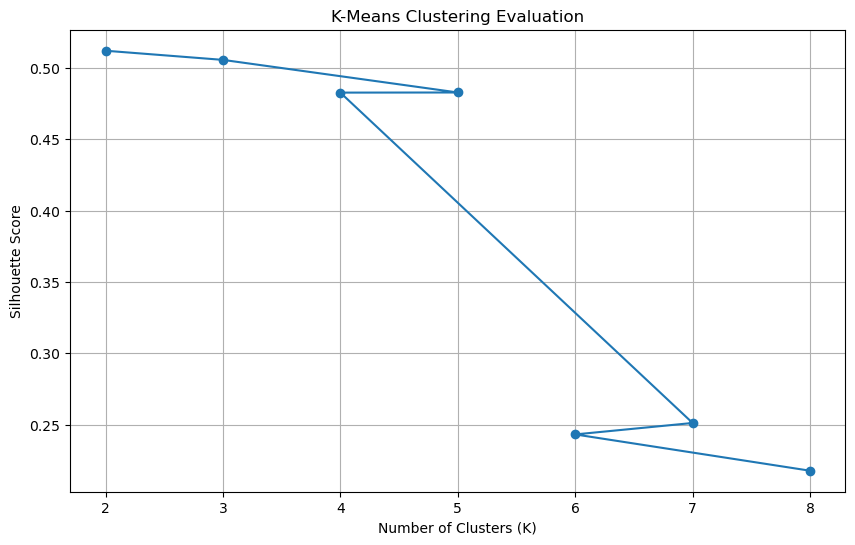

In [36]:
plt.figure(
    figsize=(10, 6)
)

plt.plot(
    model_evaluation_df[
        "k"
    ],
    model_evaluation_df[
        "silhouette_score"
    ],
    marker="o"
)

plt.xlabel(
    "Number of Clusters (K)"
)

plt.ylabel(
    "Silhouette Score"
)

plt.title(
    "K-Means Clustering Evaluation"
)

plt.xticks(
    model_evaluation_df[
        "k"
    ]
)

plt.grid(
    True
)

plt.show()

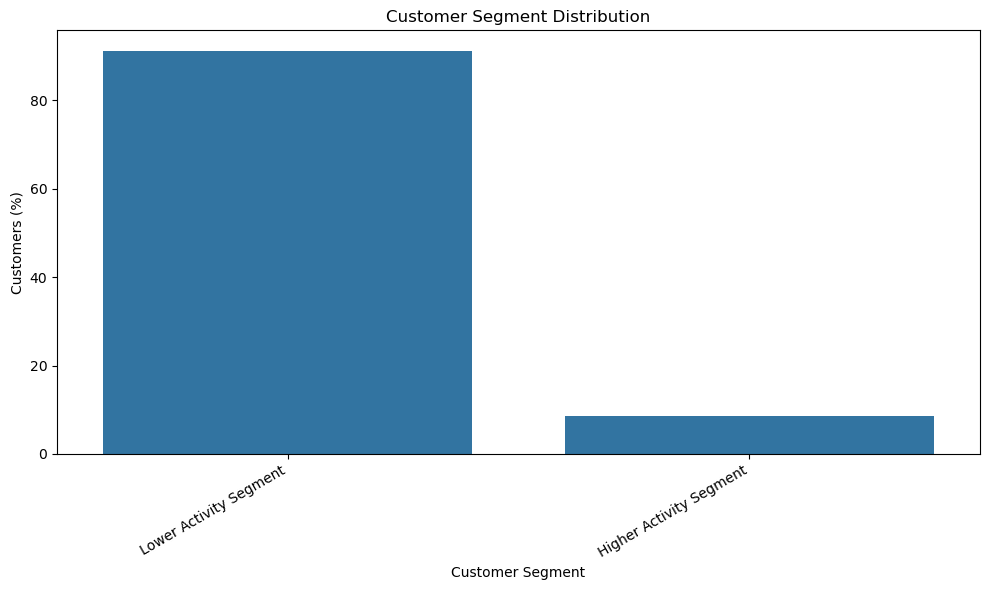

In [37]:
plt.figure(
    figsize=(10, 6)
)

sns.barplot(
    data=segment_distribution_df,
    x="segment_name",
    y="customer_percentage"
)

plt.xlabel(
    "Customer Segment"
)

plt.ylabel(
    "Customers (%)"
)

plt.title(
    "Customer Segment Distribution"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.show()

In [38]:
segment_feature_means_df = (
    customer_segmentation_df
    .groupby(
        [
            "cluster_id",
            "segment_name"
        ],
        as_index=False
    )[
        CLUSTER_FEATURE_COLUMNS
    ]
    .mean()
)

display(
    segment_feature_means_df
)

,cluster_id,segment_name,customer_zip_code_prefix,total_spend,average_order_value,total_items_purchased,average_review_score,average_delivery_days,average_delivery_delay_days,late_orders,cancelled_orders,recency_days,monetary
0,0,Lower Activity Segment,34946.167076,157.336392,157.336392,1.136458,4.210367,11.180296,-12.700198,0.000000,0.000033,293.069378,157.336392
1,1,Higher Activity Segment,37146.978019,180.226851,180.226851,1.094748,2.425671,31.215266,8.632937,0.905484,0.071957,273.474013,180.226851


In [39]:
customer_output_file = os.path.join(
    OUTPUT_PATH,
    "customer_segmentation.csv"
)

segment_summary_output_file = os.path.join(
    OUTPUT_PATH,
    "segment_summary.csv"
)

segment_distribution_output_file = os.path.join(
    OUTPUT_PATH,
    "segment_distribution.csv"
)

model_evaluation_output_file = os.path.join(
    OUTPUT_PATH,
    "model_evaluation.csv"
)

segment_feature_means_output_file = os.path.join(
    OUTPUT_PATH,
    "segment_feature_means.csv"
)

customer_segmentation_df.to_csv(
    customer_output_file,
    index=False
)

cluster_summary_df.to_csv(
    segment_summary_output_file,
    index=False
)

segment_distribution_df.to_csv(
    segment_distribution_output_file,
    index=False
)

evaluation_results_final_df.to_csv(
    model_evaluation_output_file,
    index=False
)

segment_feature_means_df.to_csv(
    segment_feature_means_output_file,
    index=False
)

print("CSV files exported successfully:")
print(customer_output_file)
print(segment_summary_output_file)
print(segment_distribution_output_file)
print(model_evaluation_output_file)
print(segment_feature_means_output_file)

CSV files exported successfully:
C:\Users\asus\Documents\ECOMMERCE-AI-PLATFORM\data\processed\customer_segmentation\customer_segmentation.csv
C:\Users\asus\Documents\ECOMMERCE-AI-PLATFORM\data\processed\customer_segmentation\segment_summary.csv
C:\Users\asus\Documents\ECOMMERCE-AI-PLATFORM\data\processed\customer_segmentation\segment_distribution.csv
C:\Users\asus\Documents\ECOMMERCE-AI-PLATFORM\data\processed\customer_segmentation\model_evaluation.csv
C:\Users\asus\Documents\ECOMMERCE-AI-PLATFORM\data\processed\customer_segmentation\segment_feature_means.csv


In [40]:
customer_segmentation_table_name = (
    "customer_segmentation"
)

segment_summary_table_name = (
    "segment_summary"
)

segment_distribution_table_name = (
    "segment_distribution"
)

model_evaluation_table_name = (
    "customer_segmentation_model_evaluation"
)

segment_feature_means_table_name = (
    "segment_feature_means"
)

with engine.begin() as connection:
    
    customer_segmentation_df.to_sql(
        customer_segmentation_table_name,
        connection,
        schema=ANALYTICS_SCHEMA,
        if_exists="replace",
        index=False,
        method="multi",
        chunksize=1000
    )
    
    cluster_summary_df.to_sql(
        segment_summary_table_name,
        connection,
        schema=ANALYTICS_SCHEMA,
        if_exists="replace",
        index=False,
        method="multi",
        chunksize=1000
    )
    
    segment_distribution_df.to_sql(
        segment_distribution_table_name,
        connection,
        schema=ANALYTICS_SCHEMA,
        if_exists="replace",
        index=False,
        method="multi",
        chunksize=1000
    )
    
    evaluation_results_final_df.to_sql(
        model_evaluation_table_name,
        connection,
        schema=ANALYTICS_SCHEMA,
        if_exists="replace",
        index=False,
        method="multi",
        chunksize=1000
    )
    
    segment_feature_means_df.to_sql(
        segment_feature_means_table_name,
        connection,
        schema=ANALYTICS_SCHEMA,
        if_exists="replace",
        index=False,
        method="multi",
        chunksize=1000
    )

print("Power BI-ready PostgreSQL tables created successfully.")

Power BI-ready PostgreSQL tables created successfully.


In [41]:
analytics_tables_query = text("""
SELECT
    table_schema,
    table_name
FROM information_schema.tables
WHERE table_schema = :schema_name
ORDER BY table_name
""")

analytics_tables_df = pd.read_sql(
    analytics_tables_query,
    engine,
    params={
        "schema_name": ANALYTICS_SCHEMA
    }
)

print(
    f'Tables currently available in '
    f'"{ANALYTICS_SCHEMA}":'
)

display(
    analytics_tables_df
)

Tables currently available in "analytics":


,table_schema,table_name
0,analytics,customer_segmentation
1,analytics,customer_segmentation_model_evaluation
2,analytics,segment_distribution
3,analytics,segment_feature_means
4,analytics,segment_summary


In [42]:
output_validation = {
    "customer_segmentation_rows": len(
        customer_segmentation_df
    ),
    "segment_summary_rows": len(
        cluster_summary_df
    ),
    "segment_distribution_rows": len(
        segment_distribution_df
    ),
    "model_evaluation_rows": len(
        evaluation_results_final_df
    ),
    "segment_feature_means_rows": len(
        segment_feature_means_df
    ),
    "unique_customer_ids": customer_segmentation_df[
        SELECTED_CUSTOMER_ID_COLUMN
    ].nunique(),
    "unique_clusters": customer_segmentation_df[
        "cluster_id"
    ].nunique(),
    "unique_segments": customer_segmentation_df[
        "segment_name"
    ].nunique(),
    "best_k": BEST_K,
    "best_silhouette_score": float(
        model_evaluation_df.loc[
            0,
            "silhouette_score"
        ]
    )
}

output_validation_df = pd.DataFrame(
    [
        output_validation
    ]
)

display(
    output_validation_df
)

,customer_segmentation_rows,segment_summary_rows,segment_distribution_rows,model_evaluation_rows,segment_feature_means_rows,unique_customer_ids,unique_clusters,unique_segments,best_k,best_silhouette_score
0,99441,2,2,7,2,99441,2,2,2,0.51208


In [43]:
assert not customer_segmentation_df.empty

assert not cluster_summary_df.empty

assert not segment_distribution_df.empty

assert not evaluation_results_final_df.empty

assert (
    customer_segmentation_df[
        SELECTED_CUSTOMER_ID_COLUMN
    ]
    .duplicated()
    .sum()
    == 0
)

assert (
    customer_segmentation_df[
        "cluster_id"
    ]
    .notna()
    .all()
)

assert (
    customer_segmentation_df[
        "segment_name"
    ]
    .notna()
    .all()
)

assert (
    customer_segmentation_df[
        CLUSTER_FEATURE_COLUMNS
    ]
    .notna()
    .all()
    .all()
)

assert np.isfinite(
    customer_segmentation_df[
        CLUSTER_FEATURE_COLUMNS
    ]
    .to_numpy(
        dtype=float
    )
).all()

assert (
    len(
        segment_distribution_df
    )
    == customer_segmentation_df[
        "cluster_id"
    ].nunique()
)

print(
    "All final customer segmentation validation checks passed."
)

All final customer segmentation validation checks passed.


In [44]:
print("=" * 70)
print("CUSTOMER SEGMENTATION COMPLETED SUCCESSFULLY")
print("=" * 70)

print("\nVerified source table:")
print(
    f"{FEATURE_SCHEMA}.{SELECTED_TABLE}"
)

print("\nVerified customer identifier:")
print(
    SELECTED_CUSTOMER_ID_COLUMN
)

print("\nFeatures used:")
for column in CLUSTER_FEATURE_COLUMNS:
    print("-", column)

print("\nNumber of customers:")
print(
    len(
        customer_segmentation_df
    )
)

print("\nNumber of clusters:")
print(
    BEST_K
)

print("\nNumber of segments:")
print(
    customer_segmentation_df[
        "segment_name"
    ].nunique()
)

print("\nBest silhouette score:")
print(
    round(
        model_evaluation_df.loc[
            0,
            "silhouette_score"
        ],
        4
    )
)

print("\nPostgreSQL output schema:")
print(
    ANALYTICS_SCHEMA
)

print("\nCSV output folder:")
print(
    OUTPUT_PATH
)

print("\nNotebook 09 completed successfully.")

CUSTOMER SEGMENTATION COMPLETED SUCCESSFULLY

Verified source table:
feature_engineered.customer_features

Verified customer identifier:
customer_id

Features used:
- customer_zip_code_prefix
- total_spend
- average_order_value
- total_items_purchased
- average_review_score
- average_delivery_days
- average_delivery_delay_days
- late_orders
- cancelled_orders
- recency_days
- monetary

Number of customers:
99441

Number of clusters:
2

Number of segments:
2

Best silhouette score:
0.5121

PostgreSQL output schema:
analytics

CSV output folder:
C:\Users\asus\Documents\ECOMMERCE-AI-PLATFORM\data\processed\customer_segmentation

Notebook 09 completed successfully.
